In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Gis pkgs
import geopandas as gpd
import overpass
import shapely
from shapely.geometry import Point, LineString, Polygon, MultiPoint

# Mapping pkgs
import folium
import folium.plugins
import branca.colormap as cm

plt.style.use("bmh")

In [21]:
def get_filt_df(df):
    speed_diff = np.diff(df["speed"])
    speed_diff = np.insert(speed_diff,0,0)

    df["speed_diff"] = np.abs(speed_diff)
    df = df[df["speed_diff"].between(0,10)].copy()
    df["speed_diff_range"]  = pd.cut(df["speed_diff"],bins=5)

    df_filt = df[df["speed_diff"].between(-1,1)].copy()
    return df_filt




In [22]:
# Lectura datos
pavimentos_file = "pavimentos_Castellon_17Nov_Noche.csv"
abrev = "castellon_noche"
#pavimentos_file = "pavimentos_Castellon_17Nov_Tarde.csv"
#pavimentos_file = "pavimentos_Castellon_17Nov_Noche.csv"

vel_ref = 30
df_pavimentos = pd.read_csv(pavimentos_file)
df_pavimentos = df_pavimentos[df_pavimentos["lat"] > 1].copy()


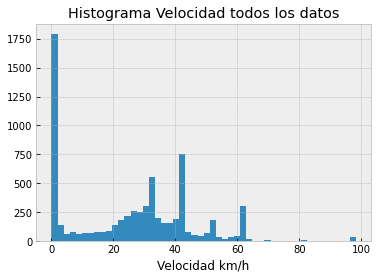

In [23]:
df_pavimentos["speed"].hist(bins=50)
plt.xlabel("Velocidad km/h")
plt.title("Histograma Velocidad todos los datos");

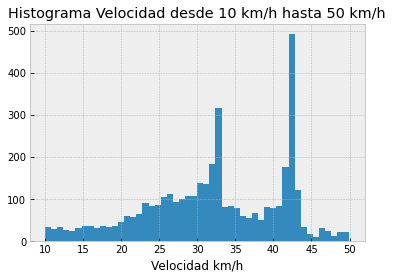

In [24]:
df_pavimentos = df_pavimentos[df_pavimentos["speed"] > 10].copy()
df_pavimentos = df_pavimentos[df_pavimentos["speed"] < 50].copy()

df_pavimentos["speed"].hist(bins=50)
plt.xlabel("Velocidad km/h");
plt.title("Histograma Velocidad desde 10 km/h hasta 50 km/h");

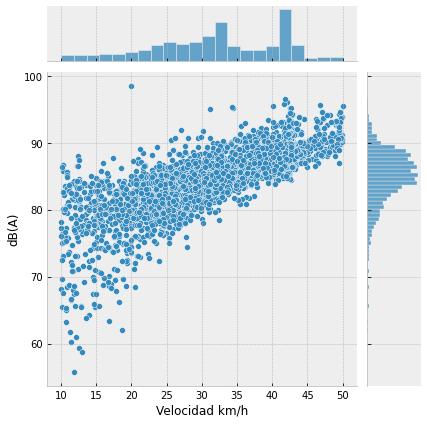

In [25]:
sns.jointplot(data=df_pavimentos, x="speed", y="LA");
plt.xlabel("Velocidad km/h");
plt.ylabel("dB(A)");
#plt.title("Relación Niveles y velocidad");

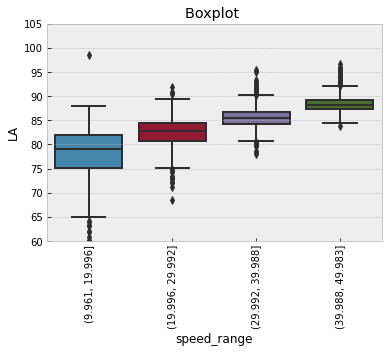

In [26]:
df_pavimentos["speed_range"] = pd.cut(df_pavimentos["speed"],bins=4)
sns.boxplot(data=df_pavimentos,x="speed_range",y="LA")
plt.ylim([60,105])
plt.xticks(rotation=90);
plt.title("Boxplot ");

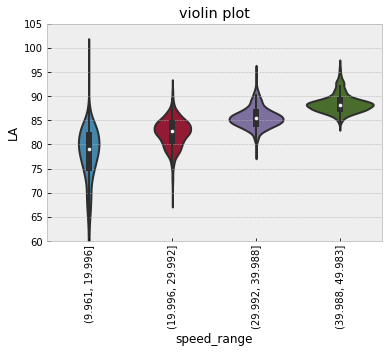

In [27]:
df_pavimentos["speed_range"] = pd.cut(df_pavimentos["speed"],bins=4)
sns.violinplot(data=df_pavimentos,x="speed_range",y="LA")
plt.ylim([60,105])
plt.xticks(rotation=90);
plt.title("violin plot");

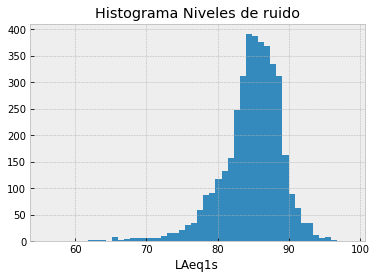

In [28]:
df_pavimentos["LA"].hist(bins=50)
plt.xlabel("LAeq1s");
plt.title("Histograma Niveles de ruido");

In [29]:
mod = smf.ols(formula='LA ~ np.log10(speed)', data=df_pavimentos)
res = mod.fit()
print(res.summary())
print(res.params)

                            OLS Regression Results                            
Dep. Variable:                     LA   R-squared:                       0.595
Model:                            OLS   Adj. R-squared:                  0.595
Method:                 Least Squares   F-statistic:                     5840.
Date:                Mon, 24 Apr 2023   Prob (F-statistic):               0.00
Time:                        11:05:54   Log-Likelihood:                -9673.0
No. Observations:                3975   AIC:                         1.935e+04
Df Residuals:                    3973   BIC:                         1.936e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          49.9349      0.457    1

C:\Users\CALC_C~1\AppData\Local\Temp/ipykernel_28996/3095047613.py:3: RuntimeWarning: divide by zero encountered in log10
  fit_model = res_params[0] + res_params[1]*np.log10(speed_vec)


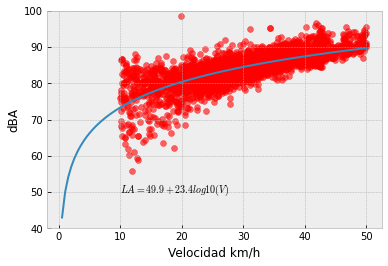

In [30]:
res_params = res.params
speed_vec = np.linspace(0,50,100)
fit_model = res_params[0] + res_params[1]*np.log10(speed_vec)

plt.scatter(df_pavimentos["speed"], df_pavimentos["LA"],color="red",alpha=0.6)
plt.text(10,50,f"$LA = {round(res_params[0],1)} + {round(res_params[1],1)}log10(V)$")
plt.plot(speed_vec,fit_model)
plt.ylim([40,100])
plt.ylabel("dBA");
plt.xlabel("Velocidad km/h");

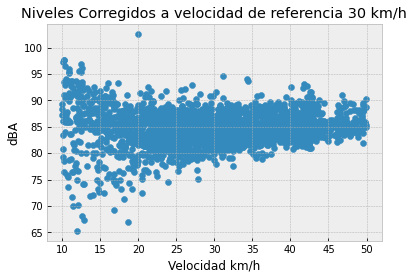

In [31]:
LA_corrected = df_pavimentos["LA"] - res_params[1]*np.log10(df_pavimentos["speed"]/vel_ref)
plt.scatter(df_pavimentos["speed"],LA_corrected)
df_pavimentos["LA_corrected"] = LA_corrected
plt.title("Niveles Corregidos a velocidad de referencia 30 km/h");
plt.ylabel("dBA");
plt.xlabel("Velocidad km/h");

In [32]:
LA_expected = res_params[0] + res_params[1]*np.log10(vel_ref)
print("25 km/h: ",res_params[0] + res_params[1]*np.log10(vel_ref - 5))
print("30 km/h: ",res_params[0] + res_params[1]*np.log10(vel_ref))
print("35 km/h: ",res_params[0] + res_params[1]*np.log10(vel_ref + 5))

25 km/h:  82.67960261615832
30 km/h:  84.53430819284964
35 km/h:  86.10243941415925


Nivel esperado a 30 km/h: 84.53430819284964


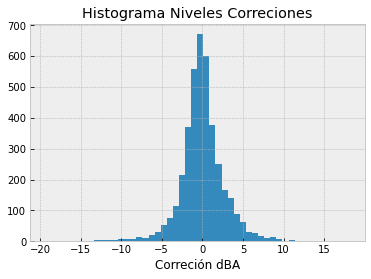

In [33]:
LA_expected = res_params[0] + res_params[1]*np.log10(vel_ref)
print(f"Nivel esperado a {vel_ref} km/h: {LA_expected}")
df_pavimentos["correction"] = df_pavimentos["LA_corrected"] - LA_expected 

df_pavimentos["correction"].hist(bins=50)
plt.xlabel("Correción dBA")
plt.title("Histograma Niveles Correciones");

In [38]:
df_pavimentos.to_csv(f'correction_values_{abrev}.csv')

## Gis postprocess

In [34]:
df_pavimentos['geometry'] = df_pavimentos.apply(lambda x: Point(x['lat'],x['lon']),axis=1)
df_pavimentos = df_pavimentos[df_pavimentos["lat"] > 1].copy()

C:\Users\CALC_COLOMBIA\anaconda3\lib\site-packages\pandas\core\dtypes\cast.py:127: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.0. Convert the '.coords' to a numpy array instead.
  arr = construct_1d_object_array_from_listlike(values)


In [35]:
step = 10
lines = []
rounded_len = int(np.floor(len(df_pavimentos) / step)) * step
mean_df_pavimentos = pd.DataFrame()
dates = []


for i in range(0,rounded_len-step,step):
    df_pavimentos_temp = df_pavimentos.iloc[i:i+step]
    df_pavimentos_num = df_pavimentos_temp.select_dtypes(include=np.number)
    mean_df_pavimentos = pd.concat([mean_df_pavimentos,df_pavimentos_num.mean()],axis=1)
    #lines.append(LineString([df_pavimentos_temp['geometry'].values[0],df_pavimentos_temp['geometry'].values[-1]]))
    lines.append(LineString(list(df_pavimentos_temp['geometry'].values)))
    dates.append(df_pavimentos_temp['system_date'].iloc[0])
    
mean_df_pavimentos = mean_df_pavimentos.T
mean_df_pavimentos['geometry'] = lines
mean_df_pavimentos['system_date'] = dates

C:\Users\CALC_COLOMBIA\anaconda3\lib\site-packages\pandas\core\dtypes\cast.py:127: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.0. Convert the '.coords' to a numpy array instead.
  arr = construct_1d_object_array_from_listlike(values)


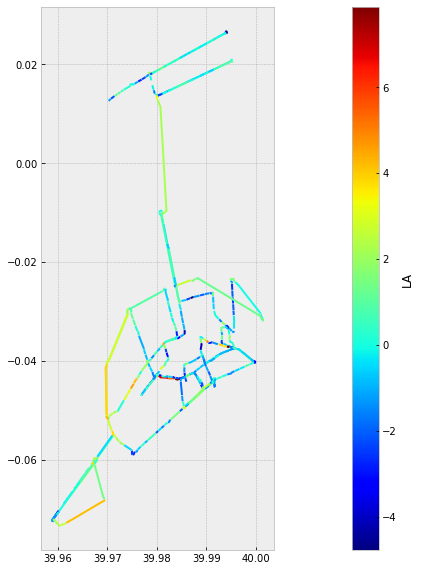

In [36]:
# to geodataframe
mean_df_geo = gpd.GeoDataFrame(mean_df_pavimentos,crs="EPSG:4326")
df_geo = gpd.GeoDataFrame(df_pavimentos,crs="EPSG:4326")

mean_df_geo.plot(column='correction',legend=True,legend_kwds={'label': "LA"},figsize=(28,10),cmap='jet');

In [37]:
  ## save speed maps
this_map = folium.Map(prefer_canvas=True)
variable = 'correction'
#v_min = df_pavimentos[variable].min()
#v_max = df_pavimentos[variable].max()
v_min=-6
v_max=6
index_list = list(np.linspace(v_min,v_max,5))
step = cm.LinearColormap(colors=['green','yellow', 'blue', 'purple','red'],index=index_list,vmin=v_min,vmax=v_max)

def plotDot(point):
    '''input: series that contains a numeric named latitude and a numeric named longitude
    this function creates a CircleMarker and adds it to your this_map'''
    folium.CircleMarker(location=[point.lat, point.lon],
                        fill=True,
                        color=step(point[variable]),
                        radius=2).add_to(this_map)

#use df_pavimentos.apply(,axis=1) to "iterate" through every row in your dataframe
df_pavimentos.apply(plotDot, axis = 1)

#Set the zoom to the maximum possible
tile = folium.TileLayer(
        tiles = 'https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
        #tiles = '',
        attr = 'Aerial',
        name = 'Mapquest',
        overlay = False,
        control = True
    ).add_to(this_map)
this_map.fit_bounds(this_map.get_bounds())
this_map.add_child(step)

this_map.save(f'correction_map_{abrev}.html')